<h1 align="left">VisionToText Model Metrics</h1>

<p align="left">
  ITESM
  
  <a href="https://www.linkedin.com/in/juanrtato/">Juan Ricardo Albarracin B.</a>
  <br>
  <a href="">Luis Ángel Oporto Añacato.</a>
  <br>
  <a href="">David Alexis García Espinosa.</a>
  <br>
  <b>Last updated:</b> <i>15/06/2025</i>
  <br><br>
  <a target="_blank">
    <img src="https://github.com/QData/TextAttack/workflows/Github%20PyTest/badge.svg" alt="Testing">
  </a>
  <a href="https://img.shields.io/badge/version-0.1.0-blue.svg?cacheSeconds=2592000">
    <img src="https://img.shields.io/badge/version-0.1.0-blue.svg?cacheSeconds=2592000" alt="Version" height="18">
  </a>
</p><br>

In [1]:
CONFIG_PATH = '../datalake/config_vtt.json'
TSVIT_MODEL_PATH = '../datalake/TSVIT/best.pth'
VTT_MODEL_PATH = '../scripts/outputs/v1_no_dropout/model_vtt_gpt2_epoch_10.pth'
VTT_losses = '../scripts/outputs/v1_no_dropout/losses_model_vtt_gpt2.json'

In [2]:
import sys
import os
import json
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'scripts')))

In [3]:
import torch
from visiontotext import visiontotextmodel
from tsvit import torch_utils, model_architecture
from test_eval import compute_metrics
from pastis24 import get_dataloaders
from matplotlib import pyplot as plt

/home/juanrtato/miniconda3/envs/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/juanrtato/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/juanrtato/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [4]:
device_ids = [0]
with open(CONFIG_PATH, 'r') as f:
    config = json.load(f)

with open(VTT_losses, 'r') as f:
    losses = json.load(f)

In [5]:
dataloader_vtt = get_dataloaders(config)

Loading PASTIS2SEQUENCE dataset...
PASTIS2SEQUENCE dataset loaded!


In [6]:
import torch
print(torch.cuda.is_available())  
print(torch.cuda.device_count())  

True
1


In [7]:
device = torch_utils.get_device(device_ids, allow_cpu=False)

In [8]:
vtt_model = visiontotextmodel.get_visiontotext_model(
    config,
    device,
    TSVIT_MODEL_PATH
)

In [9]:
vtt_model.load_state_dict(torch.load(VTT_MODEL_PATH, map_location=device))

<All keys matched successfully>

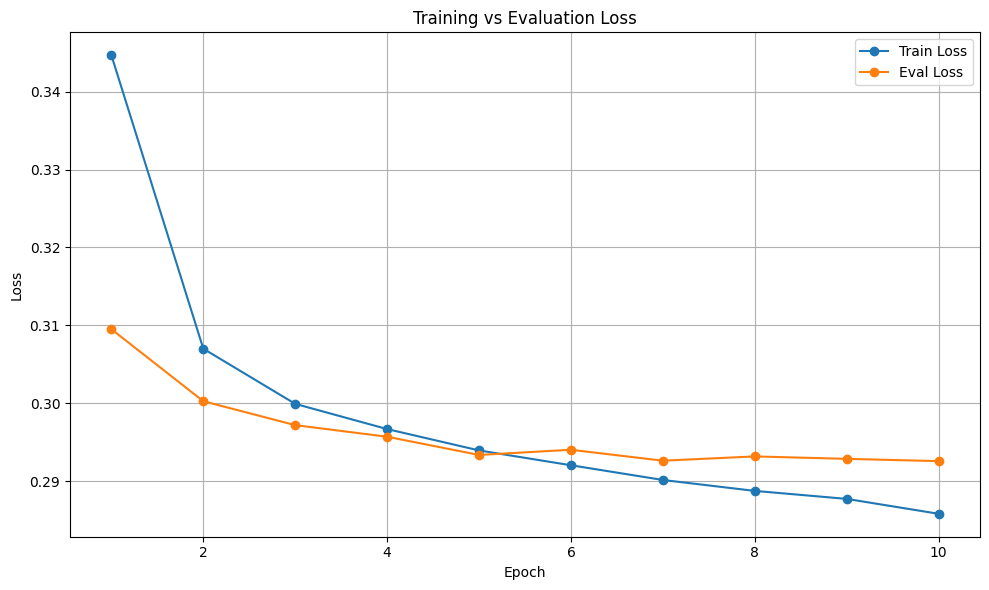

In [10]:
epochs = list(range(1, len(losses["train_loss"]) + 1))
plt.figure(figsize=(10, 6))
plt.plot(epochs, losses["train_loss"], label='Train Loss', marker='o')
plt.plot(epochs, losses["eval_loss"], label='Eval Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Evaluation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
print(losses)

{'train_loss': [0.3446674677580202, 0.30701072747502134, 0.299935870020009, 0.29669928741407897, 0.2939605178350784, 0.2920577991016622, 0.29016875004823417, 0.2887665172965121, 0.2877412739806958, 0.2858292778270776], 'eval_loss': [0.30951494875535446, 0.3002761034823176, 0.2972049794090328, 0.29571720458085266, 0.29338099845309756, 0.29404326668426173, 0.29264312119626285, 0.29319092483069764, 0.29288022454401746, 0.2925865556915008]}


In [ ]:
from itertools import islice
#small_dataloader = list(islice(dataloader_vtt['eval'], 5000))

ERROR: Unexpected bus error encountered in worker. This might be caused by insufficient shared memory (shm).
 ERROR: Unexpected bus error encountered in worker. This might be caused by insufficient shared memory (shm).
 

RuntimeError: DataLoader worker (pid(s) 55770) exited unexpectedly

In [11]:
print(len(dataloader_vtt['train'].dataset))
print(len(dataloader_vtt['eval'].dataset))

36375
12050


In [18]:
metrics = compute_metrics(vtt_model, small_dataloader, device)

Ref:  Description of the agricultural activity seen in the image: The image reflects the crop of Meadow with an approximate area of 29700 m2, Winter barley spanning approximately 12500 m2 which constitutes an important part of the agricultural area in the region.

On the topic of crop development stages, the life cycle of Meadow spanned from about the midpoint of October to about about late March. To add to that, the observed agricultural timeline for Winter barley suggests planting around the midpoint of October and harvesting in mid-March.
Pred: Description of the agricultural activity seen in the image: Meadow with an estimated size of 48600 m2 which corresponds to a relevant part of the cultivated area in this zone.

Concerning the seasonal periods, the life cycle of Meadow spanned from around the midpoint of October to about in the middle of March.
METEOR: 0.3749 | BLEU: 0.2430
------
Ref:  Description of the agricultural activity seen in the image: The crop of Grapevine can be se

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🤖 BERTScore promedio: 0.4698
🌾 METEOR promedio:    0.4175
📘 BLEU promedio:      0.2012
🧪 Score combinado:    0.4437


In [19]:
metrics

{'bert': 0.4698347747325897,
 'meteor': 0.4174839791172696,
 'bleu': 0.20116255760259746,
 'combined': 0.4436593769249296,
 'per_sample': [{'img_path': '../datalake/PASTIS24/pickle24x24/30460_10.pickle',
   'ground_truth': 'Description of the agricultural activity seen in the image: The image reflects the crop of Meadow with an approximate area of 29700 m2, Winter barley spanning approximately 12500 m2 which constitutes an important part of the agricultural area in the region.\n\nOn the topic of crop development stages, the life cycle of Meadow spanned from about the midpoint of October to about about late March. To add to that, the observed agricultural timeline for Winter barley suggests planting around the midpoint of October and harvesting in mid-March.',
   'prediction': 'Description of the agricultural activity seen in the image: Meadow with an estimated size of 48600 m2 which corresponds to a relevant part of the cultivated area in this zone.\n\nConcerning the seasonal periods, 

In [ ]:
import csv
with open("../datalake/models/metrics.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=metrics[0].keys())
    writer.writeheader()
    writer.writerows(metrics)